In [1]:
pip install pandas



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install mysql-connector-python



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip intsall seaborn


ERROR: unknown command "intsall" - maybe you meant "install"
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    #('customers.csv', 'customers'),
    #('orders.csv', 'orders'),
    #('sellers.csv', 'sellers'),
    #('products.csv', 'products'),
    #('geolocation.csv', 'geolocation'),
    #('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')
     # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='12345678',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = "/Users/macbookpro/Downloads/Target Sales Dataset"

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close() 


Processing order_items.csv
NaN values before replacement:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64



In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "12345678",
                             database = "ecommerce")

cur = db.cursor()

In [8]:
import numpy as np

# 1. List all unique cities where customers are located.      

In [9]:
query = """ select distinct(customer_city) from customers """

cur.execute(query)

data = cur.fetchall()

data


[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# 2. Count the number of orders placed in 2017.

In [10]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """

cur.execute(query)

data = cur.fetchall()
'count of orders from 2017 is ',data[0][0]

('count of orders from 2017 is ', 45101)

# 3. Find the total sales per category.

In [11]:
query = """ select upper(products.product_category) as category, round(sum(payments.payment_value),2) as sales 
            from products join order_items on 
            products.product_id = order_items.product_id
            join payments on 
            payments.order_id = order_items.order_id
            group by category"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category" , "Sales"])
df.head(10)



,Category,Sales
0,PERFUMERY,1013477.32
1,FURNITURE DECORATION,2860352.78
2,TELEPHONY,973764.10
3,BED TABLE BATH,3425107.34
4,AUTOMOTIVE,1704588.66
5,COMPUTER ACCESSORIES,3170660.89
6,HOUSEWARES,2189516.26
7,BABIES,1079691.32
8,TOYS,1238075.38
9,FURNITURE OFFICE,1293652.97


# 4. Calculate the percentage of orders that were paid in installments.

In [12]:
query = """ select (sum( case 
                            when payment_installments >=1 then 1 else 0 end))*1.0/ count(order_id)*100 from payments"""

cur.execute(query)

data = cur.fetchall()
"The percentage of of orders that were paid in installments is ",data[0][0]

('The percentage of of orders that were paid in installments is ',
 Decimal('99.99800'))

In [13]:
query = """ select (count(distinct case 
                            when payment_installments >=1 then order_id end))*1.0/count(distinct order_id)*100 from payments"""

cur.execute(query)

data = cur.fetchall()
data[0][0]

Decimal('99.99800')

# 5. Count the number of customers from each state. 

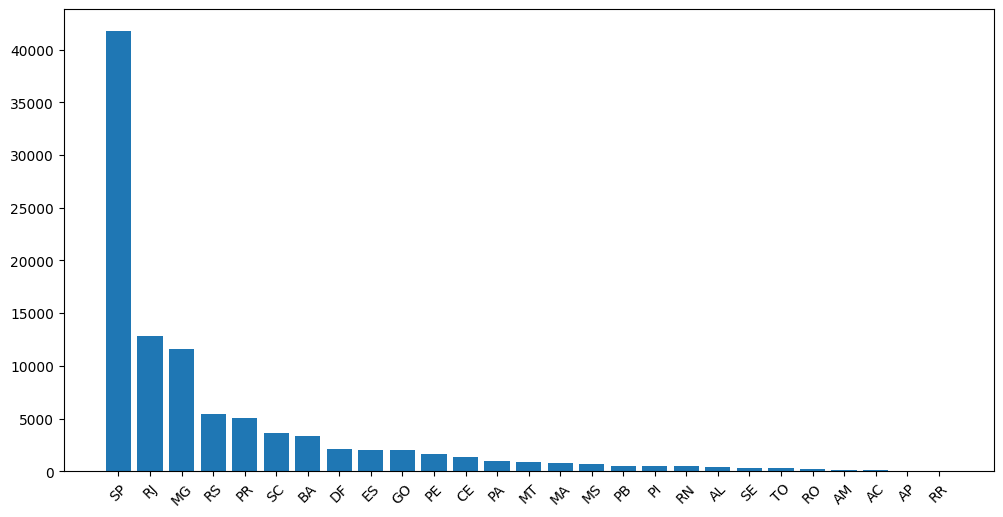

In [30]:
query = """select customer_state, count(customer_id) from customers
            group by customer_state"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["customer_state", "No_of_customers"])
df
plt.figure(figsize = (12,6))
plt.xticks(rotation = 45)
df =  df.sort_values(by = "No_of_customers", ascending = False)
plt.bar(df["customer_state"], df["No_of_customers"])
plt.show()

# Intermediate Queries

# 1. Calculate the number of orders per month in 2018.

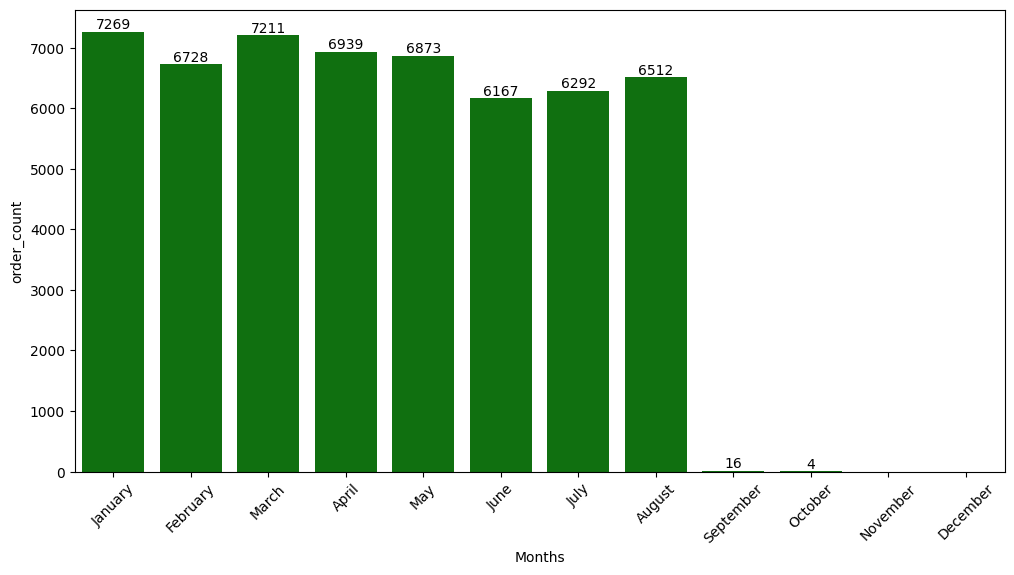

In [29]:
query = """select monthname(order_purchase_timestamp) as months, count(order_id) as orders_count 
            from orders where year(order_purchase_timestamp) = 2018 group by months """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Months", "order_count"])
df  

o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
plt.figure(figsize = (12,6))
plt.xticks(rotation = 45)
ax = sns.barplot(x = df["Months"], y = df["order_count"], data = df, order = o, color = "green")
ax.bar_label(ax.containers[0])
plt.show()

# 2. Find the average number of products per order, grouped by customer city.

In [16]:
query = """ with  product_count as (select orders.order_id, orders.customer_id, count(order_items.order_item_id) oc 
from orders join order_items on orders.order_id = 
order_items.order_id group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(product_count.oc),1) as product_avg
from customers join product_count on
customers.customer_id = product_count.customer_id
group by customers.customer_city order by product_avg desc; """

cur.execute(query)

data = cur.fetchall()
data

bd = pd.DataFrame(data, columns = ["customer_city", "product_avg"])

bd.head(10)

,customer_city,product_avg
0,padre carvalho,14.0
1,celso ramos,13.0
2,datas,12.0
3,candido godoi,12.0
4,matias olimpio,10.0
5,cidelandia,8.0
6,picarra,8.0
7,morro de sao paulo,8.0
8,teixeira soares,8.0
9,curralinho,8.0


# 3. Calculate the percentage of total revenue contributed by each product category.

In [28]:
query = """ select products.product_category as Category, 
round((sum(payments.payment_value))/(select sum(payment_value) from payments)*100,2) as Revenue
from products join order_items on 
products.product_id = order_items.product_id
join payments on payments.order_id = order_items.order_id
group by Category order by Revenue desc;
 """

cur.execute(query)

data = cur.fetchall()
bd = pd.DataFrame(data, columns = ["Product_Category", "Revenue Percentage"])
bd

#bd["Product_Category"] = bd["Product_Category"].fillna("Unknown")

#plt.barh(bd["Product_Category"], bd["Revenue Percentage"])
#plt.show

,Product_Category,Revenue Percentage
0,bed table bath,21.40
1,HEALTH BEAUTY,20.71
2,computer accessories,19.81
3,Furniture Decoration,17.87
4,Watches present,17.86
...,...,...
69,PC Gamer,0.03
70,House Comfort 2,0.02
71,cds music dvds,0.01
72,Fashion Children's Clothing,0.01


# 4. Identify the correlation between product price and the number of times a product has been purchased.

In [18]:
query = """ select products.product_id, products.product_category,
count(order_items.order_id),avg(order_items.price) 
from products join order_items on  order_items.product_id = products.product_id
group by products.product_id,products.product_category order by product_category desc; """

cur.execute(query)
data  = cur.fetchall()
bd = pd.DataFrame(data, columns = ["prod_id", "category", "count_orders", "avg_price"])
bd
import numpy as np
a = bd["count_orders"]
b = bd["avg_price"]

c = np.corrcoef([a,b])
c

#print("The correlation between saloes count and price of product is ", c[0][-1])

array([[ 1.        , -0.03213986],
       [-0.03213986,  1.        ]])

# 5. Calculate the total revenue generated by each seller, and rank them by revenue.

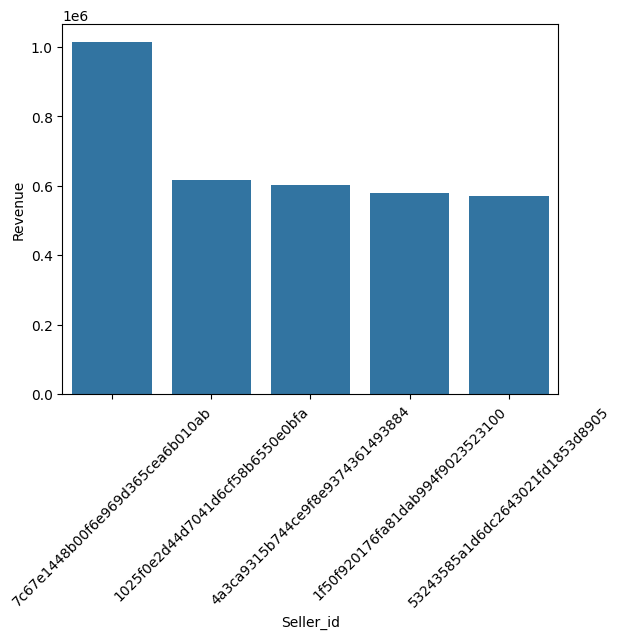

In [19]:
query = """ 
select * , dense_rank() over (order by revenue desc) from

(select order_items.seller_id, sum(payments.payment_value) as revenue
from order_items join payments on payments.order_id = 
order_items.order_id group by order_items.seller_id) as az
; """

cur.execute(query)

data = cur.fetchall()
bd = pd.DataFrame(data, columns = ["Seller_id", "Revenue", "Rank"])
bd = bd.head()
plt.xticks(rotation = 45)
sns.barplot(x = "Seller_id", y = "Revenue", data = bd)
plt.show()

# Advanced Queries

# 1. Calculate the moving average of order values for each customer over their order history.

In [20]:
query = """  
select customer_id, order_purchase_timestamp, p, avg(p)
 over(partition by customer_id order by customer_id,orders.order_purchase_timestamp
rows between unbounded preceding and current row) from  
(select orders.customer_id  , orders.order_purchase_timestamp, payments.payment_value as p
from orders join payments on payments.order_id = orders.order_id) as a
order by customer_id, order_purchase_timestamp;
 """

cur.execute(query)

data = cur.fetchall()

bd = pd.DataFrame(data)
bd


,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,9.49,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# 2. Calculate the cumulative sales per month for each year.

In [21]:
query = """ select years, months, sum(payments) over(order by years, months) from

(select year(orders.order_purchase_timestamp) as years, 
month(orders.order_purchase_timestamp) as months, round(sum(payments.payment_value),2) 
as payments
from orders join payments on payments.order_id = 
orders.order_id group by years, months order by years) as sas """

cur.execute(query)

data = cur.fetchall()

bd = pd.DataFrame(data)

bd

,0,1,2
0,2016,9,252.24
1,2016,10,59342.72
2,2016,12,59362.34
3,2017,1,197850.38
4,2017,2,489758.39
5,2017,3,939621.99
6,2017,4,1357410.02
7,2017,5,1950328.84
8,2017,6,2461605.22
9,2017,7,3053988.14


# 3. Calculate the year-over-year growth rate of total sales.

In [22]:
query = """ 
with ds as(select year(orders.order_purchase_timestamp) as years, sum(payments.payment_value) as payment
from orders join payments on payments.order_id = orders.order_id
group by years order by years)

select years, payment, round((payment - (lag(payment,1) over(order by years))) /lag(payment,1) over(order by years),2) *100 from ds """

cur.execute(query)

data = cur.fetchall()

bd = pd.DataFrame(data)
bd

,0,1,2
0,2016,5.936234e+04,NaN
1,2017,7.249747e+06,12113.0
2,2018,8.699763e+06,20.0


# 4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase

In [23]:
query = """ with a as (select customers.customer_id, min(orders.order_purchase_timestamp)
 as first_order from customers join orders on 
orders.customer_id = customers.customer_id group by customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp)
from a join orders on a.customer_id = orders.customer_id
and orders.order_purchase_timestamp > first_order and
orders.order_purchase_timestamp <= date_add(first_order, interval 6 month)
group by a.customer_id)

select 100 * ((count(distinct b.customer_id)/
(count(distinct a.customer_id)))) from a left join b on b.customer_id = 
a.customer_id  """

cur.execute(query)

data = cur.fetchall()

bd = pd.DataFrame(data)
bd

,0
0,0.0000


# 5. Identify the top 3 customers who spent the most money in each year.

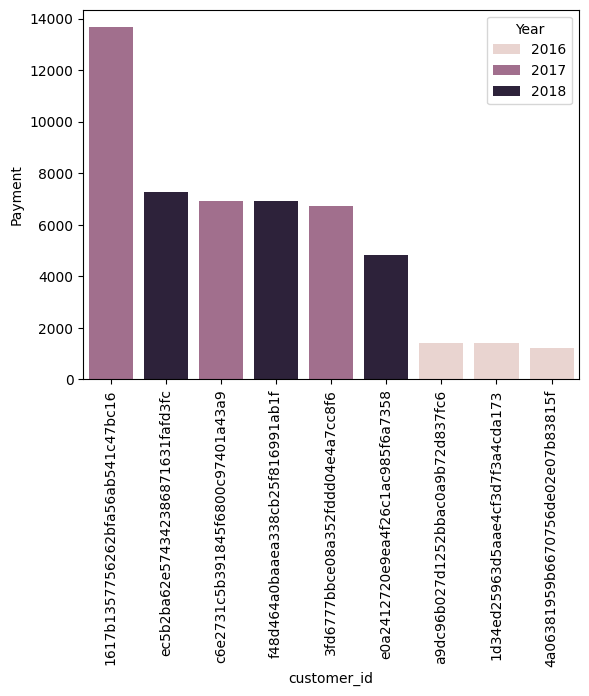

In [26]:
query = """ select *  from 

(select orders.customer_id, year(orders.order_purchase_timestamp),
sum(payments.payment_value) as payments, dense_rank() 
over(partition by year(orders.order_purchase_timestamp) order by sum(payments.payment_value) desc) as z from orders
join payments on
payments.order_id = orders.order_id group by 
year(orders.order_purchase_timestamp), customer_id) as t

where z <=3; 
 """

cur.execute(query)

data = cur.fetchall()
bd = pd.DataFrame(data, columns = ["customer_id", "Year", "Payment", "Rank"])
bd
bd = bd.sort_values(by="Payment", ascending = False)
plt.xticks(rotation = 90)

sns .barplot(x = "customer_id", y = "Payment", data = bd, hue = "Year")
plt.show()